# XLA HLO와 PyTorch FX 그래프 그리기

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Jake-Song/tensor2silicon/blob/main/notebooks/xla_fx_graphviz.ipynb)

같은 작은 함수 **Y = ReLU(X @ W + b)** 를 두 프레임워크에서 실행하고, 실제 추출한 그래프를 Graphviz로 그립니다. **CPU만으로 실행**할 수 있습니다.

- PyTorch FX: Python 함수에서 포착한 연산 그래프
- XLA HLO: JAX에서 lowering한, **백엔드 최적화 전** HLO 그래프

서로 다른 표현 수준이므로 노드 개수가 같을 필요는 없습니다. 그림의 노드는 GPU 커널이나 하드웨어 블록을 뜻하지 않습니다.

후반부에서는 `L = sum(ReLU(X @ W + b))`의 역전파까지 포함합니다. PyTorch AOTAutograd의 조인트 그래프 및 분리된 순전파·역전파 FX 그래프와 JAX의 손실·gradient를 함께 담은 HLO를 비교합니다.


## 1. 준비

현재 커널에 패키지가 없다면 아래 명령을 별도 코드 셀에서 실행한 후 커널을 재시작하세요. 기존 환경을 불필요하게 변경하지 않도록 설치를 자동 실행하지 않습니다.

```python
%pip install torch --index-url https://download.pytorch.org/whl/cpu
%pip install jax graphviz
```

Python `graphviz` 패키지 외에 시스템 **Graphviz (`dot`)** 도 필요합니다.

- Ubuntu / Colab: 터미널에서 `sudo apt-get install graphviz` (Colab 셀에서는 `!apt-get -qq install graphviz`)
- macOS: 터미널에서 `brew install graphviz`

로컬 Jupyter를 새로 준비할 경우 같은 Python 환경에 `jupyterlab`을 설치하고 `jupyter lab`으로 이 노트북을 여세요.


In [1]:
from pathlib import Path
import shutil
import subprocess

assert shutil.which("dot"), "Graphviz 실행 파일 dot이 없습니다. 위의 시스템 설치 안내를 확인하세요."

import numpy as np
import torch
from torch.fx import symbolic_trace
from torch.fx.passes.shape_prop import ShapeProp
import jax
import jax.numpy as jnp
import graphviz
from IPython.display import SVG, display

print("PyTorch:", torch.__version__)
print("JAX:", jax.__version__)
print("Python graphviz:", graphviz.__version__)
print(subprocess.run(["dot", "-V"], capture_output=True, text=True, check=True).stderr.strip())
cpu = jax.devices("cpu")[0]
print("실행 장치: PyTorch cpu / JAX", cpu)

# 저장소 루트 또는 notebooks 디렉터리에서 실행할 수 있습니다.
notebook_dir = Path("notebooks") if Path("notebooks").is_dir() else Path.cwd()
output_dir = notebook_dir / "graphs"
output_dir.mkdir(parents=True, exist_ok=True)
print("그림 저장 위치:", output_dir.resolve())


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


PyTorch: 2.14.0+cpu
JAX: 0.11.2
Python graphviz: 0.21
dot - graphviz version 2.43.0 (0)
실행 장치: PyTorch cpu / JAX cpu:0
그림 저장 위치: /home/jake/tensor2silicon/notebooks/graphs


## 2. 동일한 입력과 간단한 예제

`X: (2, 3)`, `W: (3, 2)`, `b: (2,)` → `Y: (2, 2)` 입니다.
음수와 양수가 섞인 값을 사용해 ReLU가 음수를 0으로 만드는 것도 확인합니다. 가중치와 편향을 함수 인자로 전달하므로 그래프에서 세 입력을 모두 볼 수 있습니다.


In [2]:
x_np = np.array([[1, -2, 3], [-1, 2, -3]], dtype=np.float32)
w_np = np.array([[1, -1], [2, 0], [-1, 2]], dtype=np.float32)
b_np = np.array([0.5, -0.5], dtype=np.float32)


def torch_forward(x, w, b):
    return torch.relu(x @ w + b)


def jax_forward(x, w, b):
    # ReLU를 maximum으로 직접 표현해 간단한 HLO 그래프를 얻습니다.
    return jnp.maximum(x @ w + b, 0.0)


torch_args = tuple(torch.from_numpy(a.copy()) for a in (x_np, w_np, b_np))
jax_args = tuple(jax.device_put(a, cpu) for a in (x_np, w_np, b_np))
expected = np.maximum(x_np @ w_np + b_np, 0)
print("ReLU 이전:\n", x_np @ w_np + b_np)
print("기대 출력:\n", expected)


ReLU 이전:
 [[-5.5  4.5]
 [ 6.5 -5.5]]
기대 출력:
 [[0.  4.5]
 [6.5 0. ]]


## 3. PyTorch FX: 추적 → 텍스트 → 그래프

`symbolic_trace`가 `matmul`, `add`, `relu`를 기록합니다. `ShapeProp`은 예제 입력으로 각 노드의 shape과 dtype을 채웁니다.

아래 시각화 함수는 `gm.graph.nodes`와 각 노드의 `all_input_nodes`에서 실제 연결을 읽습니다. 입력은 파랑, 연산은 노랑, 출력은 초록입니다.


In [3]:
gm = symbolic_trace(torch_forward)
ShapeProp(gm).propagate(*torch_args)
print(gm.graph)
print("생성된 Python 코드:")
print(gm.code)


graph():
    %x : [num_users=1] = placeholder[target=x]
    %w : [num_users=1] = placeholder[target=w]
    %b : [num_users=1] = placeholder[target=b]
    %matmul : [num_users=1] = call_function[target=operator.matmul](args = (%x, %w), kwargs = {})
    %add : [num_users=1] = call_function[target=operator.add](args = (%matmul, %b), kwargs = {})
    %relu : [num_users=1] = call_function[target=torch.relu](args = (%add,), kwargs = {})
    return relu
생성된 Python 코드:



def forward(self, x, w, b):
    matmul = x @ w;  x = w = None
    add = matmul + b;  matmul = b = None
    relu = torch.relu(add);  add = None
    return relu
    


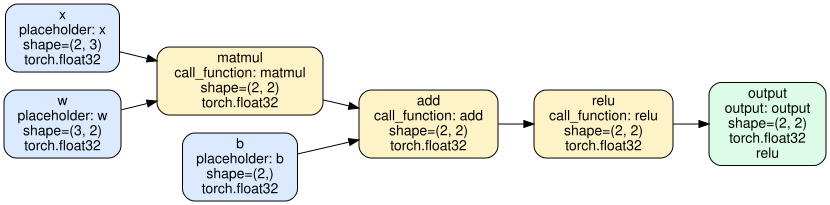

저장: pytorch_fx.dot / pytorch_fx.svg


In [4]:
def draw_fx(graph_module, name="pytorch_fx", rankdir="LR"):
    dot = graphviz.Digraph(name, graph_attr={"rankdir": rankdir})
    dot.attr("node", shape="box", style="rounded,filled", fontname="Helvetica")
    for node in graph_module.graph.nodes:
        target = getattr(node.target, "__name__", str(node.target))
        label = f"{node.name}\n{node.op}: {target}"
        meta = node.meta.get("tensor_meta")
        if meta is None:
            meta = node.meta.get("val")  # AOTAutograd의 FakeTensor 메타데이터
        if hasattr(meta, "shape") and hasattr(meta, "dtype"):
            label += f"\nshape={tuple(meta.shape)}\n{meta.dtype}"
        if node.op == "output":
            label += f"\n{node.args[0]}"  # 저장되는 값과 gradient의 반환 순서
        color = {"placeholder": "#DBEAFE", "output": "#DCFCE7"}.get(node.op, "#FEF3C7")
        dot.node(node.name, label=label, fillcolor=color)
        for parent in node.all_input_nodes:
            dot.edge(parent.name, node.name)
    return dot


def show_and_save(dot_source, name):
    source = graphviz.Source(dot_source)
    svg = source.pipe(format="svg")
    (output_dir / f"{name}.dot").write_text(dot_source, encoding="utf-8")
    (output_dir / f"{name}.svg").write_bytes(svg)
    display(SVG(data=svg.decode("utf-8")))
    print(f"저장: {name}.dot / {name}.svg")
    return svg


fx_dot = draw_fx(gm)
fx_svg = show_and_save(fx_dot.source, "pytorch_fx")


## 4. XLA HLO: lowering → 텍스트 → 그래프

JAX의 `lower` 결과에서 HLO 표현을 요청합니다. `as_hlo_dot_graph()`가 생성한 DOT를 그대로 렌더링하므로, 손으로 그린 개념도가 아닙니다.

이 그림은 `.compile()` 이후의 최적화된 HLO가 아닙니다. 노드 이름과 broadcast·reshape의 세부 표현은 JAX/jaxlib 버전에 따라 달라질 수 있습니다.


HloModule jit_jax_forward, entry_computation_layout={(f32[2,3]{1,0}, f32[3,2]{1,0}, f32[2]{0})->f32[2,2]{1,0}}, frontend_attributes={xla.sdy.meshes={empty_mesh = #sdy.mesh<[]>}}

ENTRY main.1 {
  x.1 = f32[2,3]{1,0} parameter(0), sharding={replicated}, frontend_attributes={xla.sdy.sharding="#sdy.sharding<@empty_mesh, [{}, {}]>"}
  w.1 = f32[3,2]{1,0} parameter(1), sharding={replicated}, frontend_attributes={xla.sdy.sharding="#sdy.sharding<@empty_mesh, [{}, {}]>"}
  dot_general.1 = f32[2,2]{1,0} dot(x.1, w.1), lhs_contracting_dims={1}, rhs_contracting_dims={0}
  b.1 = f32[2]{0} parameter(2), sharding={replicated}, frontend_attributes={xla.sdy.sharding="#sdy.sharding<@empty_mesh, [{}]>"}
  broadcast_in_dim.1 = f32[1,2]{1,0} reshape(b.1)
  add.4 = f32[1,2]{1,0} broadcast(broadcast_in_dim.1), dimensions={0,1}
  add.5 = f32[2]{0} reshape(add.4)
  add.6 = f32[2,2]{1,0} broadcast(add.5), dimensions={1}
  add.7 = f32[2,2]{1,0} add(dot_general.1, add.6)
  constant.1 = f32[] constant(0)
  broadc

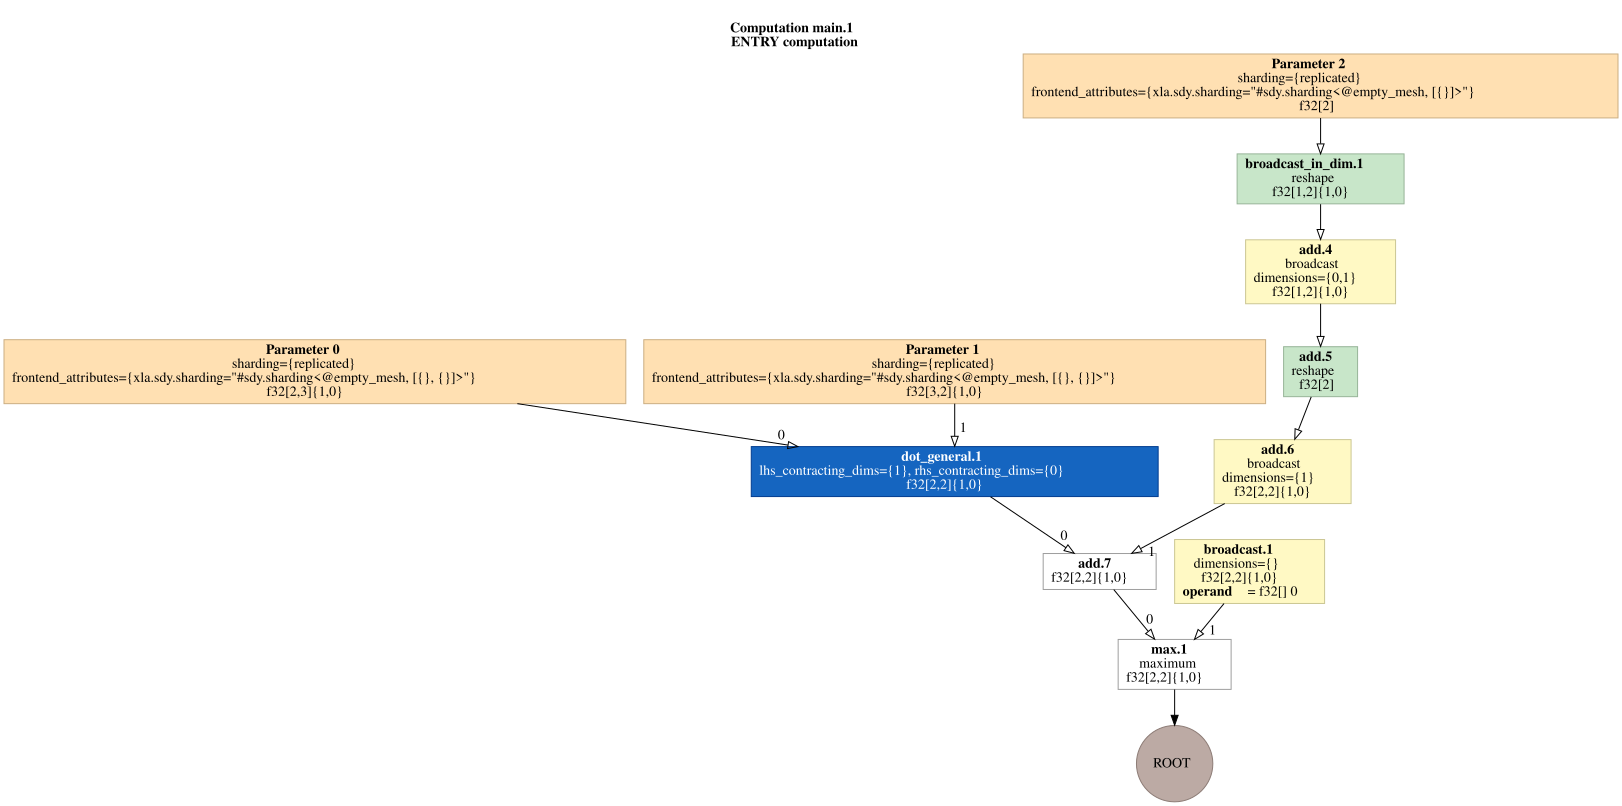

저장: xla_hlo.dot / xla_hlo.svg


In [5]:
lowered = jax.jit(jax_forward).lower(*jax_args)
hlo = lowered.compiler_ir(dialect="hlo")
print(hlo.as_hlo_text())

hlo_dot = hlo.as_hlo_dot_graph()
hlo_svg = show_and_save(hlo_dot, "xla_hlo")


## 5. 같은 계산인지 검증하고 비교하기

| 계산 | PyTorch FX | XLA HLO에서 찾을 연산 |
|---|---|---|
| 입력 X, W, b | placeholder | parameter |
| X @ W | matmul | dot |
| 편향 더하기 | add, 암묵적 broadcasting | broadcast / reshape와 add |
| ReLU | relu | 0 상수의 broadcast와 maximum |
| 결과 | output 노드 | ROOT로 표시된 연산 |

FX의 간단한 연산이 HLO에서는 여러 노드로 표현될 수 있습니다. 두 그래프 모두 동일한 수치 결과를 내는지 확인합니다.


In [6]:
results = {
    "PyTorch 원본": torch_forward(*torch_args).detach().numpy(),
    "PyTorch FX": gm(*torch_args).detach().numpy(),
    "JAX JIT": np.asarray(jax.jit(jax_forward)(*jax_args)),
}
for name, result in results.items():
    np.testing.assert_allclose(result, expected, rtol=1e-5, atol=1e-6)
    print(f"{name}: 일치\n{result}")

assert b"<svg" in fx_svg and b"<svg" in hlo_svg
print("두 그래프의 SVG 렌더링 완료")


PyTorch 원본: 일치
[[0.  4.5]
 [6.5 0. ]]
PyTorch FX: 일치
[[0.  4.5]
 [6.5 0. ]]
JAX JIT: 일치
[[0.  4.5]
 [6.5 0. ]]
두 그래프의 SVG 렌더링 완료


## 6. 역전파를 위한 스칼라 손실

같은 예제에 합계를 붙여 **L = sum(ReLU(X @ W + b))** 로 정의합니다. `X`, `W`, `b` 모두에 대해 미분하며, optimizer 업데이트는 다루지 않습니다.

앞의 JAX 예제는 그림을 단순화하려고 `maximum`을 사용했습니다. 학습 예제에서는 **`jax.nn.relu`** 를 사용해 입력이 정확히 0일 때도 PyTorch와 동일하게 미분값 0을 사용합니다.

`Z = X @ W + b`, `M = (Z > 0)`라 하면 다음 식으로 자동미분 결과를 검증할 수 있습니다.

- `dL/dX = M @ W.T`
- `dL/dW = X.T @ M`
- `dL/db = sum(M, axis=0)` — 편향 broadcasting의 역전파는 합산입니다.


In [7]:
def torch_loss(x, w, b):
    return torch_forward(x, w, b).sum()


def jax_loss(x, w, b):
    return jax.nn.relu(x @ w + b).sum()


def fresh_torch_args(arrays):
    # 매 실행마다 새 leaf tensor를 만들어 gradient 누적을 방지합니다.
    return tuple(torch.tensor(a, dtype=torch.float32, requires_grad=True) for a in arrays)


train_args = fresh_torch_args((x_np, w_np, b_np))


## 7. PyTorch: 조인트 그래프 → 순전파 FX / 역전파 FX

`symbolic_trace` 자체는 역전파 그래프를 생성하지 않습니다. 여기서는 **AOTAutograd**의 `aot_function`에 두 compiler callback을 등록해 실제 순전파·역전파 FX 그래프를 받습니다.

이는 `torch.compile` 학습 경로에서도 쓰이는 AOTAutograd의 분리를 직접 살펴보는 예제입니다. Dynamo·Inductor 전체 파이프라인을 실행하는 것은 아니며, callback이 돌려주는 FX 코드를 CPU에서 실행합니다. `functorch.compile`은 컴파일러 실험용 API라 PyTorch 버전에 따라 변경될 수 있습니다.

순전파는 손실 외에도 역전파에 필요한 값을 반환합니다. `.backward()`는 저장된 값과 손실의 upstream gradient(`dL/dL = 1`)를 사용하며, 이때 역전파 callback까지 실행됩니다.

분할 직전에 `partition_fn` callback에서 **조인트 그래프를 복사**하고, 원본은 `default_partition`으로 전달합니다. 따라서 같은 AOTAutograd 실행에서 분할 전후를 비교할 수 있습니다.


In [8]:
from copy import deepcopy
from functorch.compile import aot_function, make_boxed_func, default_partition

captured = {}


def capture_graph(name):
    def compiler(graph_module, example_inputs):
        captured[name] = graph_module
        # AOTAutograd가 요구하는 boxed 호출 규약을 사용합니다.
        return make_boxed_func(graph_module.forward)
    return compiler


def capture_joint(joint_module, joint_inputs, **partition_kwargs):
    # partitioner가 원본을 변경하기 전에 분할 전 그래프를 보존합니다.
    captured["joint"] = deepcopy(joint_module)
    assert partition_kwargs["num_fwd_outputs"] == 1  # 이 예제의 순전파 출력은 손실 하나
    return default_partition(joint_module, joint_inputs, **partition_kwargs)


compiled_loss = aot_function(
    torch_loss,
    fw_compiler=capture_graph("forward"),
    bw_compiler=capture_graph("backward"),
    partition_fn=capture_joint,
)
aot_loss = compiled_loss(*train_args)
aot_loss.backward()
assert set(captured) == {"joint", "forward", "backward"}
print("손실:", aot_loss.item())
print("포착한 그래프:", list(captured))


손실: 11.0
포착한 그래프: ['joint', 'forward', 'backward']


### 7-1. 분할 전 조인트 그래프

**입력:** 원래 입력 `X, W, b` (`primals`)와 손실에 들어오는 gradient (`tangents`). **출력:** `(L, dX, dW, db)`.

파랑은 입력, 노랑은 손실 계산에 필요한 연산, 보라는 추가 미분 연산, 초록은 출력입니다. 색은 손실 출력까지의 실제 의존 관계로 구분한 학습용 표시이며, partitioner의 내부 분류를 그대로 나타내지는 않습니다.

ReLU의 결과가 손실 합계와 역전파 마스크 계산으로 갈라지는 연결을 살펴보세요. 이후 분할 과정에서는 이런 값을 순전파 출력에 추가해 역전파로 전달합니다. 아래의 두 개별 그래프는 이 조인트 그래프를 나눈 결과입니다.


분할 전 조인트 그래프 코드:



def forward(self, primals, tangents):
    primals_1, primals_2, primals_3, tangents_1, = fx_pytree.tree_flatten_spec([primals, tangents], self._in_spec)
    mm = torch.ops.aten.mm.default(primals_1, primals_2)
    add = torch.ops.aten.add.Tensor(mm, primals_3);  mm = primals_3 = None
    relu = torch.ops.aten.relu.default(add);  add = None
    detach = torch.ops.aten.detach.default(relu)
    sum_1 = torch.ops.aten.sum.default(relu);  relu = None
    expand = torch.ops.aten.expand.default(tangents_1, [2, 2]);  tangents_1 = None
    detach_1 = torch.ops.aten.detach.default(detach);  detach = None
    threshold_backward = torch.ops.aten.threshold_backward.default(expand, detach_1, 0);  expand = detach_1 = None
    sum_2 = torch.ops.aten.sum.dim_IntList(threshold_backward, [0], True)
    view = torch.ops.aten.view.default(sum_2, [2]);  sum_2 = None
    t = torch.ops.aten.t.default(primals_1);  primals_1 = None
    mm_1 = torch.ops.aten.mm.default(t, threshold_backward);

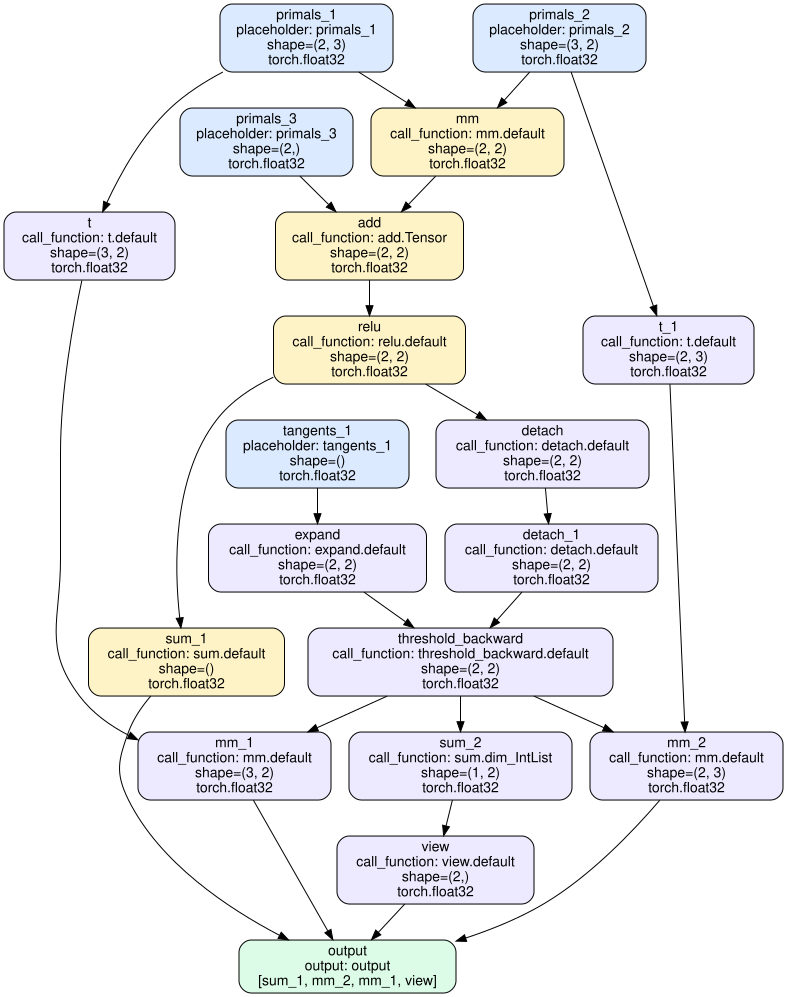

저장: pytorch_aot_joint.dot / pytorch_aot_joint.svg
조인트 그래프 실행 검증 완료: seed=1, 2에서 손실 유지 및 gradient 배율 일치


In [9]:
joint = captured["joint"]
joint.graph.lint()
print("분할 전 조인트 그래프 코드:")
print(joint.code)

output_node = next(node for node in joint.graph.nodes if node.op == "output")
joint_outputs = output_node.args[0]
assert len(joint_outputs) == 4  # 손실, dX, dW, db

# 순전파 손실에 필요한 노드를 실제 연결을 따라 찾습니다.
forward_nodes = set()
pending = [joint_outputs[0]]
while pending:
    node = pending.pop()
    if node not in forward_nodes:
        forward_nodes.add(node)
        pending.extend(node.all_input_nodes)

joint_dot = draw_fx(joint, "pytorch_aot_joint", rankdir="TB")
for node in joint.graph.nodes:
    if node.op not in ("placeholder", "output"):
        joint_dot.node(node.name, fillcolor="#FEF3C7" if node in forward_nodes else "#EDE9FE")
aot_joint_svg = show_and_save(joint_dot.source, "pytorch_aot_joint")

# 분할 전 그래프 자체도 실행해 분할 후 손실 및 gradient와 비교합니다.
# Interpreter로 평탄화된 FX 입력을 직접 전달합니다.
for seed in (1.0, 2.0):
    joint_values = torch.fx.Interpreter(joint).run(
        *(t.detach() for t in train_args), torch.tensor(seed),
        enable_io_processing=False,
    )
    torch.testing.assert_close(joint_values[0], aot_loss.detach())
    for gradient, t in zip(joint_values[1:], train_args):
        torch.testing.assert_close(gradient, seed * t.grad)
print("조인트 그래프 실행 검증 완료: seed=1, 2에서 손실 유지 및 gradient 배율 일치")


### 7-2. 분할 후 순전파·역전파 그래프

AOTAutograd 순전파 코드 (손실 + 역전파용 저장값):



def forward(self, primals_1, primals_2, primals_3):
    mm = torch.ops.aten.mm.default(primals_1, primals_2)
    add = torch.ops.aten.add.Tensor(mm, primals_3);  mm = primals_3 = None
    relu = torch.ops.aten.relu.default(add);  add = None
    detach = torch.ops.aten.detach.default(relu)
    sum_1 = torch.ops.aten.sum.default(relu);  relu = None
    return (sum_1, primals_1, primals_2, detach)
    


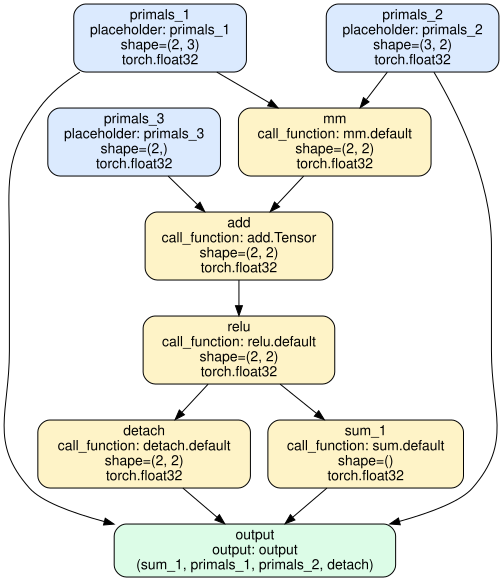

저장: pytorch_aot_forward.dot / pytorch_aot_forward.svg


In [10]:
print("AOTAutograd 순전파 코드 (손실 + 역전파용 저장값):")
print(captured["forward"].code)
aot_forward_svg = show_and_save(
    draw_fx(captured["forward"], "pytorch_aot_forward", rankdir="TB").source,
    "pytorch_aot_forward",
)


AOTAutograd 역전파 코드 (출력 순서: dX, dW, db):



def forward(self, primals_1, primals_2, detach, tangents_1):
    expand = torch.ops.aten.expand.default(tangents_1, [2, 2]);  tangents_1 = None
    detach_1 = torch.ops.aten.detach.default(detach);  detach = None
    threshold_backward = torch.ops.aten.threshold_backward.default(expand, detach_1, 0);  expand = detach_1 = None
    sum_2 = torch.ops.aten.sum.dim_IntList(threshold_backward, [0], True)
    view = torch.ops.aten.view.default(sum_2, [2]);  sum_2 = None
    t = torch.ops.aten.t.default(primals_1);  primals_1 = None
    mm_1 = torch.ops.aten.mm.default(t, threshold_backward);  t = None
    t_1 = torch.ops.aten.t.default(primals_2);  primals_2 = None
    mm_2 = torch.ops.aten.mm.default(threshold_backward, t_1);  threshold_backward = t_1 = None
    return (mm_2, mm_1, view)
    


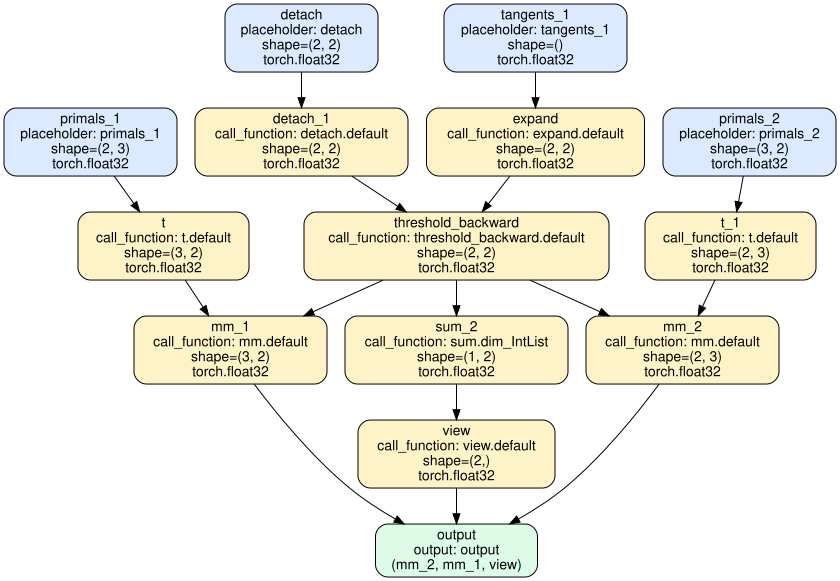

저장: pytorch_aot_backward.dot / pytorch_aot_backward.svg


In [11]:
print("AOTAutograd 역전파 코드 (출력 순서: dX, dW, db):")
print(captured["backward"].code)
aot_backward_svg = show_and_save(
    draw_fx(captured["backward"], "pytorch_aot_backward", rankdir="TB").source,
    "pytorch_aot_backward",
)


## 8. JAX / XLA: 손실과 gradient를 함께 그리기

`value_and_grad(..., argnums=(0, 1, 2))`가 손실과 `(dX, dW, db)`를 반환하는 함수를 만듭니다. 이 전체 함수를 `jit`하고 HLO를 추출합니다. **미분 계산은 JAX가 만들고, XLA가 그 계산을 컴파일합니다.**

여기서는 하나의 HLO 모듈에 손실과 미분 계산을 함께 넣었습니다. 모듈 내부에는 여러 computation이 있을 수 있고, 이것이 하나의 커널을 뜻하지는 않습니다. 그림은 앞과 동일하게 백엔드 최적화 전 HLO입니다.

### 색상 구분

- **보라:** gradient 계산에만 필요한 연산
- **노랑:** 손실 계산에만 필요한 연산
- **주황:** 손실과 gradient 계산이 공유하는 연산
- **파랑:** 입력 parameter / **초록:** 최종 출력

Graphviz가 읽은 실제 DOT 연결에서 출력 tuple의 0번(`L`)과 1~3번(`dX, dW, db`)을 역으로 따라가 색을 정합니다. 입력 parameter는 공유 여부와 관계없이 파랑으로 표시합니다. 이는 출력 의존 관계를 보여주는 학습용 분류이며, XLA의 내부 패스 구분이나 커널 경계가 아닙니다. 원래 HLO의 연산과 연결은 유지합니다.


In [12]:
import json


def color_hlo_gradients(dot_source):
    """이 예제의 (L, dX, dW, db) HLO 출력 의존 관계를 색으로 표시합니다."""
    graph = json.loads(graphviz.Source(dot_source).pipe(format="json0"))
    # Graphviz JSON은 subgraph 다음에 실제 node를 나열합니다.
    nodes = {o["_gvid"]: o for o in graph["objects"][graph["_subgraph_cnt"]:]}
    parents = {node_id: set() for node_id in nodes}
    for edge in graph["edges"]:
        parents[edge["head"]].add(edge["tail"])

    roots = [i for i, node in nodes.items() if node.get("label") == "ROOT"]
    assert len(roots) == 1, "이 예제는 ROOT 출력 하나를 예상합니다."
    root = roots[0]
    assert len(parents[root]) == 1
    output_tuple = next(iter(parents[root]))
    outputs = {
        int(edge["headlabel"]): edge["tail"]
        for edge in graph["edges"] if edge["head"] == output_tuple
    }
    assert set(outputs) == {0, 1, 2, 3}, "출력 순서는 L, dX, dW, db여야 합니다."

    def ancestors(start_nodes):
        visited, pending = set(), list(start_nodes)
        while pending:
            node_id = pending.pop()
            if node_id not in visited:
                visited.add(node_id)
                pending.extend(parents[node_id])
        return visited

    loss_nodes = ancestors([outputs[0]])
    grad_nodes = ancestors([outputs[k] for k in (1, 2, 3)])
    palette = {
        "Loss only": "#FEF3C7", "Gradient only": "#EDE9FE",
        "Shared": "#FED7AA", "Input": "#DBEAFE", "Output": "#DCFCE7",
    }
    groups = {role: [] for role in palette}
    overrides = graphviz.Digraph()
    for node_id, node in nodes.items():
        if node_id in (root, output_tuple):
            role = "Output"
        elif node.get("label", "").startswith("<b>Parameter "):
            role = "Input"
        elif node_id in loss_nodes & grad_nodes:
            role = "Shared"
        elif node_id in grad_nodes:
            role = "Gradient only"
        else:
            assert node_id in loss_nodes, "출력에서 역추적되지 않은 노드가 있습니다."
            role = "Loss only"
        groups[role].append(node["name"])
        overrides.node(node["name"], style="filled", fillcolor=palette[role],
                       fontcolor="#111827", color="#6B7280")

    # 같은 노드 ID의 색상 속성만 덮어써 원래 클러스터와 연결을 유지합니다.
    legend = "".join(f'<TD BGCOLOR="{color}">{role}</TD>' for role, color in palette.items())
    overrides.attr(label='< <TABLE BORDER="0" CELLBORDER="1" CELLSPACING="5">'
                   '<TR><TD COLSPAN="5"><B>JAX / XLA: loss + gradients</B></TD></TR>'
                   f'<TR>{legend}</TR></TABLE> >', labelloc="t")
    body, closing = dot_source.rsplit("}", 1)
    colored_dot = body + "\n" + "".join(overrides.body) + "}" + closing
    assert groups["Loss only"] and groups["Gradient only"] and groups["Shared"]
    return colored_dot, groups


HloModule jit_jax_loss, entry_computation_layout={(f32[2,3]{1,0}, f32[3,2]{1,0}, f32[2]{0})->(f32[], f32[2,3]{1,0}, f32[3,2]{0,1}, f32[2]{0})}, frontend_attributes={xla.sdy.meshes={empty_mesh = #sdy.mesh<[]>}}

relu.1 {
  Arg_0.1 = f32[2,2]{1,0} parameter(0)
  constant.4 = f32[] constant(0)
  broadcast.3 = f32[2,2]{1,0} broadcast(constant.4), dimensions={}
  ROOT max.1 = f32[2,2]{1,0} maximum(Arg_0.1, broadcast.3)
}

region_0.2 {
  reduce_sum.3 = f32[] parameter(0)
  reduce_sum.4 = f32[] parameter(1)
  ROOT reduce_sum.5 = f32[] add(reduce_sum.3, reduce_sum.4)
}

region_1.3 {
  reduce_sum.10 = f32[] parameter(0)
  reduce_sum.11 = f32[] parameter(1)
  ROOT reduce_sum.12 = f32[] add(reduce_sum.10, reduce_sum.11)
}

region_2.4 {
  reduce_sum.17 = f32[] parameter(0)
  reduce_sum.18 = f32[] parameter(1)
  ROOT reduce_sum.19 = f32[] add(reduce_sum.17, reduce_sum.18)
}

ENTRY main.5 {
  x.1 = f32[2,3]{1,0} parameter(0), sharding={replicated}, frontend_attributes={xla.sdy.sharding="#sdy.shardin

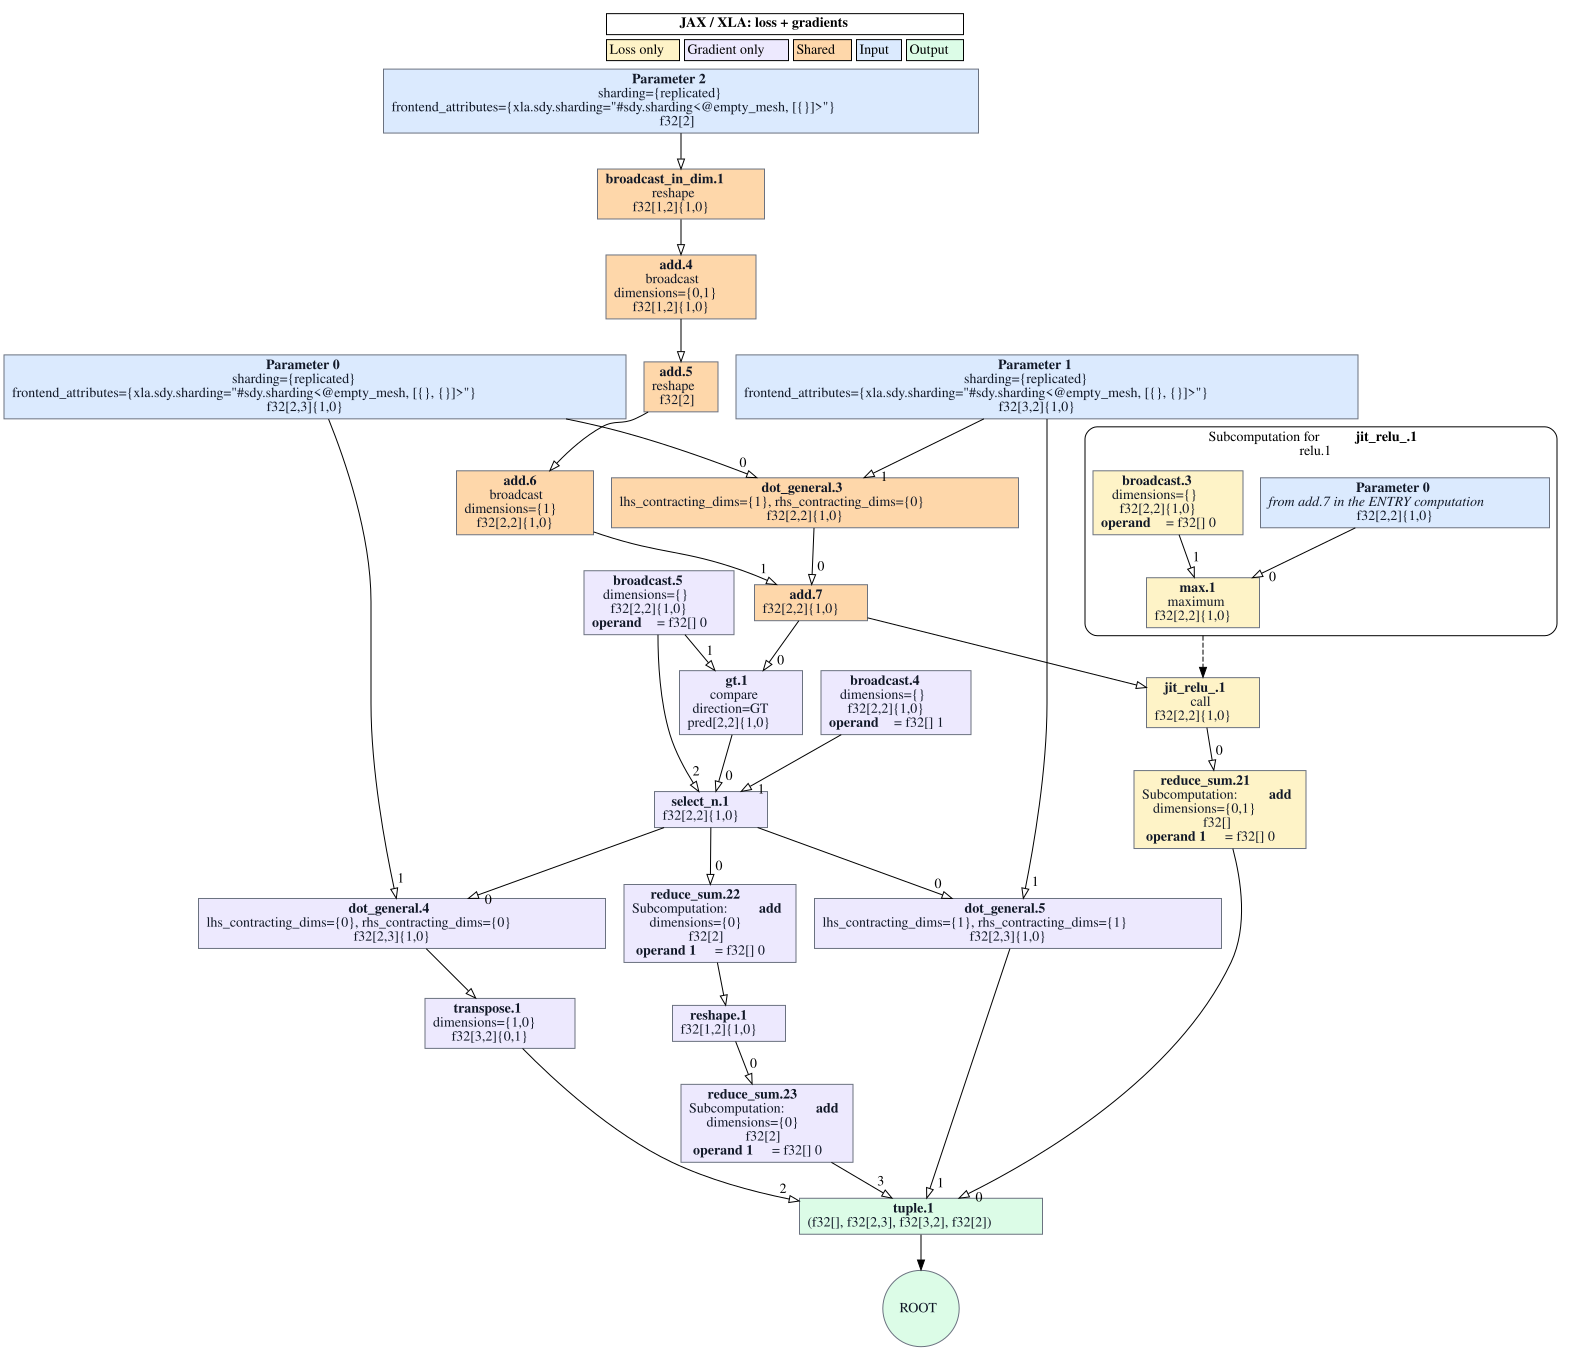

저장: xla_loss_and_grads.dot / xla_loss_and_grads.svg
색상별 노드 수: {'Loss only': 4, 'Gradient only': 10, 'Shared': 6, 'Input': 4, 'Output': 2}


JAX 손실: 11.0


In [13]:
loss_and_grads = jax.jit(jax.value_and_grad(jax_loss, argnums=(0, 1, 2)))
training_hlo = loss_and_grads.lower(*jax_args).compiler_ir(dialect="hlo")
print(training_hlo.as_hlo_text())
training_dot, hlo_color_groups = color_hlo_gradients(training_hlo.as_hlo_dot_graph())
xla_training_svg = show_and_save(training_dot, "xla_loss_and_grads")
print("색상별 노드 수:", {role: len(names) for role, names in hlo_color_groups.items()})
jax_loss_value, jax_grad_values = loss_and_grads(*jax_args)
print("JAX 손실:", float(jax_loss_value))


## 9. 손실과 세 gradient 검증

PyTorch eager autograd, PyTorch AOTAutograd, JAX JIT 결과를 위의 NumPy 해석적 미분식과 비교합니다. 양수·음수가 섞인 기본 예제에 더해 **ReLU 입력이 모두 0인 경계 사례**도 확인합니다.


In [14]:
def check_gradients(arrays, aot_value, aot_inputs, jax_value, jax_grads):
    x, w, b = arrays
    z = x @ w + b
    mask = (z > 0).astype(np.float32)
    ref_loss = np.maximum(z, 0).sum()
    ref_grads = (mask @ w.T, x.T @ mask, mask.sum(axis=0))

    eager_inputs = fresh_torch_args(arrays)
    eager_value = torch_loss(*eager_inputs)
    eager_value.backward()
    for value in (eager_value.detach().numpy(), aot_value.detach().numpy(), np.asarray(jax_value)):
        np.testing.assert_allclose(value, ref_loss, rtol=1e-5, atol=1e-6)
    for name, reference, eager_input, aot_input, jax_grad in zip(
        ("dX", "dW", "db"), ref_grads, eager_inputs, aot_inputs, jax_grads
    ):
        for gradient in (eager_input.grad.numpy(), aot_input.grad.numpy(), np.asarray(jax_grad)):
            np.testing.assert_allclose(gradient, reference, rtol=1e-5, atol=1e-6)
        print(f"{name}: eager / AOTAutograd / JAX 모두 일치\n{reference}")


print("기본 입력:")
check_gradients((x_np, w_np, b_np), aot_loss, train_args, jax_loss_value, jax_grad_values)

# 가중치는 유지하고 X와 b를 0으로 하여 Z=0 경계에서 dX, dW, db를 검증합니다.
zero_arrays = (np.zeros_like(x_np), w_np, np.zeros_like(b_np))
zero_inputs = fresh_torch_args(zero_arrays)
zero_loss = compiled_loss(*zero_inputs)
zero_loss.backward()
zero_jax_args = tuple(jax.device_put(a, cpu) for a in zero_arrays)
zero_jax_loss, zero_jax_grads = loss_and_grads(*zero_jax_args)
print("\nReLU 입력 0 경계:")
check_gradients(zero_arrays, zero_loss, zero_inputs, zero_jax_loss, zero_jax_grads)

assert all(b"<svg" in svg for svg in (aot_joint_svg, aot_forward_svg, aot_backward_svg, xla_training_svg))
print("학습 그래프 4개의 렌더링 및 손실·gradient 검증 완료")


기본 입력:
dX: eager / AOTAutograd / JAX 모두 일치
[[-1.  0.  2.]
 [ 1.  2. -1.]]
dW: eager / AOTAutograd / JAX 모두 일치
[[-1.  1.]
 [ 2. -2.]
 [-3.  3.]]
db: eager / AOTAutograd / JAX 모두 일치
[1. 1.]

ReLU 입력 0 경계:
dX: eager / AOTAutograd / JAX 모두 일치
[[0. 0. 0.]
 [0. 0. 0.]]
dW: eager / AOTAutograd / JAX 모두 일치
[[0. 0.]
 [0. 0.]
 [0. 0.]]
db: eager / AOTAutograd / JAX 모두 일치
[0. 0.]
학습 그래프 4개의 렌더링 및 손실·gradient 검증 완료


### 그래프 개수를 읽는 방법

| 이 노트북의 예제 | PyTorch | JAX / XLA |
|---|---|---|
| 순전파만 | symbolic_trace FX 1개 | 순전파 HLO 모듈 1개 |
| 손실 + 역전파 | 조인트 FX 1개 → 순전파 FX + 역전파 FX | 손실과 gradient를 함께 포함한 HLO 모듈 1개 |

**“XLA는 항상 1개, PyTorch는 항상 2개”라는 규칙은 아닙니다.** 컴파일 범위와 그래프 분할 방식에 따른 이번 예제의 결과입니다. 앞의 `symbolic_trace` 그래프와 학습용 AOT 순전파 그래프는 서로 다른 단계의 표현입니다.

조인트 그래프는 분할 전 표현입니다. 조인트·순전파·역전파 그림 세 개는 순서대로 모두 실행하는 세 단계가 아닙니다. 실제 AOT 실행에는 분할된 순전파와 역전파를 사용합니다.


## 참고 문서

- [PyTorch FX](https://docs.pytorch.org/docs/stable/fx.html)
- [JAX lowering과 컴파일 단계](https://docs.jax.dev/en/latest/aot.html)
- [Graphviz: DOT 원문 렌더링](https://graphviz.readthedocs.io/en/stable/raw_dot.html)

입력 값을 바꾸고 다시 실행해도 shape과 코드가 같으면 그래프 구조는 같습니다. 행렬 크기나 함수를 바꾼 경우에는 추적 셀부터 다시 실행하세요.

- [AOTAutograd 순전파·역전파 그래프 예제](https://github.com/pytorch/pytorch/blob/main/functorch/COMPILE_README.md)
- [JAX 자동미분과 value_and_grad](https://docs.jax.dev/en/latest/automatic-differentiation.html)
